In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_circles
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV,train_test_split
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [18]:
Xxx, yy = make_circles(n_samples=500,factor=0.1,noise=0.35,random_state=42)
Xx = pd.DataFrame(Xxx, columns=['Feature1', 'Feature2'])
print(Xx.shape, yy.shape)
print(yy)
Xx

(500, 2) (500,)
[1 0 1 0 0 1 1 0 0 1 0 0 1 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 0 0 1 1
 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 1 0 0 1 1 1 1 1
 1 1 1 0 1 1 0 0 1 0 1 0 0 1 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 1 1 0 1 0 1 0 0
 1 1 0 1 1 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 0 0 1 0 1 1 0 0
 1 1 0 0 0 0 1 1 0 0 1 0 0 1 1 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 1 1
 0 1 0 0 0 1 1 1 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 1 1 1 1 1 0 1 0 1 1
 0 0 0 1 0 1 1 0 0 0 1 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 1 0 1 1 0 1 0
 1 1 0 1 0 0 0 1 0 1 0 0 0 0 1 1 1 1 1 1 0 1 0 1 0 0 1 1 1 1 1 1 1 1 1 0 0
 1 1 1 1 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 1 1 0 1 1 0 1 0 1 0 1 0 0 0 1 0 0 0
 0 0 0 1 1 0 0 0 0 1 1 0 0 1 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 0 0 0 0 1 1 0 1
 0 1 0 1 1 0 1 0 0 0 0 1 0 1 1 0 1 0 0 0 1 1 1 0 1 1 1 1 0 0 0 1 1 1 1 1 1
 1 1 0 0 0 0 1 0 1 1 0 0 1 0 1 1 0 1 0 0 0 1 1 1 0 1 1 0 1 1 0 0 1 0 1 1 0
 1 1 0 1 1 1 0 0 1 0 1 0 1 0 1 0 0 0 0 1 0 1 0 1 1 0 1 1 0 1 1 1 1 1 1 0 0
 0 1 0 1 

,Feature1,Feature2
0,-0.093239,0.299042
1,0.415898,1.110238
2,0.098751,0.054377
3,-0.318616,-0.498557
4,-0.601736,1.136758
...,...,...
495,-0.828943,0.547630
496,0.370969,-0.410317
497,-0.648872,0.616103
498,-0.509287,-0.527586


In [19]:
Q1 = Xx.quantile(0.25)
Q3 = Xx.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_mask = ((Xx < lower) | (Xx > upper)).any(axis=1)

print("Number of outliers:", outlier_mask.sum())

X= Xx[~outlier_mask]
y= yy[~outlier_mask]

print("After removing outliers:")
print(X.shape, y.shape)

Number of outliers: 13
After removing outliers:
(487, 2) (487,)


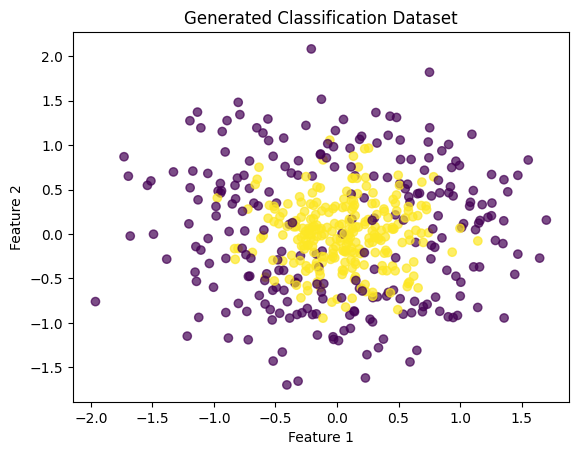

In [20]:
plt.scatter(Xx.iloc[:, 0], Xx.iloc[:, 1], c=yy, cmap='viridis', alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated Classification Dataset")
plt.show()


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [22]:
model=AdaBoostClassifier()
model.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [23]:
print(accuracy_score(y_train,model.predict(X_train)))
print(accuracy_score(y_test,model.predict(X_test)))

0.8560411311053985
0.826530612244898


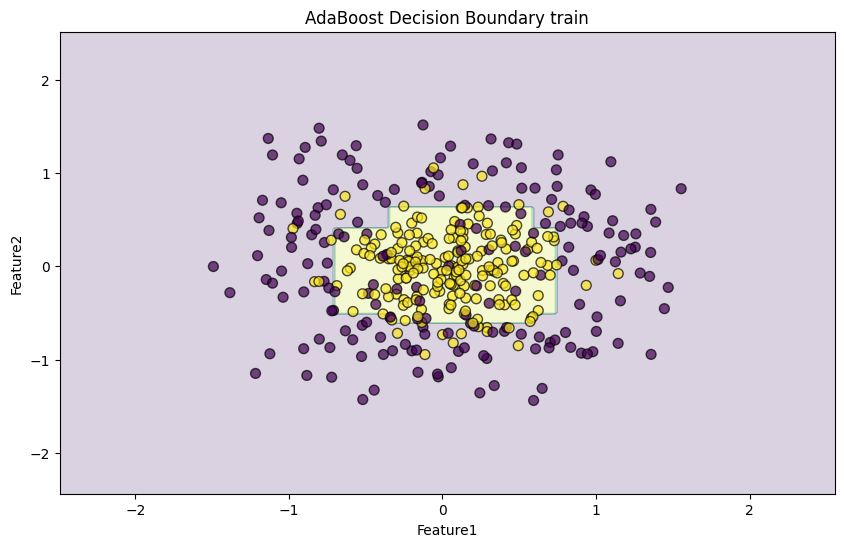

In [24]:
def plot_decision_boundary(X, y, clf, title="Decision Boundary"):
    plt.figure(figsize=(10, 6))
    X_np = X.values
    x_min, x_max = X_np[:, 0].min() - 1, X_np[:, 0].max() + 1
    y_min, y_max = X_np[:, 1].min() - 1, X_np[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.linspace(x_min, x_max, 200),np.linspace(y_min, y_max, 200))
    grid = pd.DataFrame(np.c_[xx1.ravel(), xx2.ravel()], columns=X.columns)
    y_hat = clf.predict(grid).reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_hat, alpha=0.2, cmap='viridis')
    plt.scatter(X_np[:, 0], X_np[:, 1], c=y, cmap='viridis', edgecolor='k', s=50, alpha=0.7)
    plt.title(title)
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.show()
plot_decision_boundary(X_train,y_train, model, title="AdaBoost Decision Boundary train")

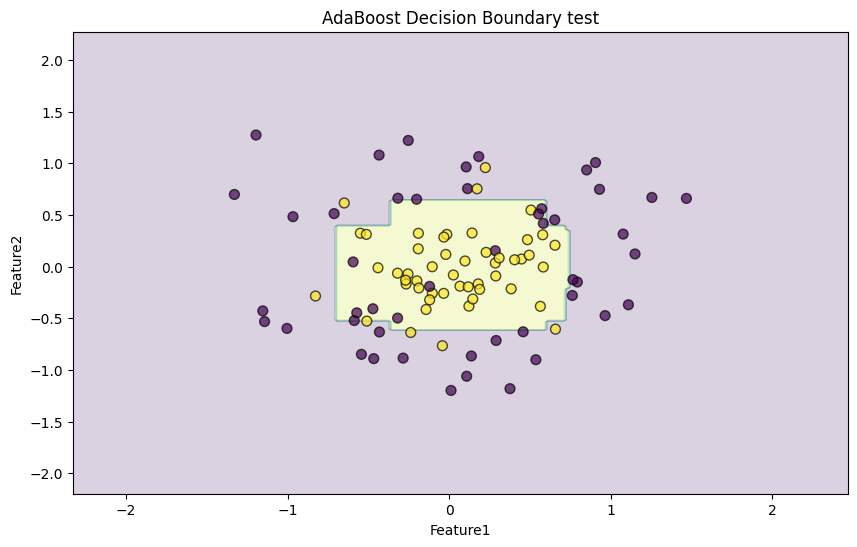

In [25]:
plot_decision_boundary(X_test,y_test, model, title="AdaBoost Decision Boundary test")

In [26]:
dd=pd.DataFrame()
dd["Predict"]=model.predict(X)
dd["Actual"]=y
correct = (dd["Predict"] == dd["Actual"]).sum()
incorrect = (dd["Predict"] != dd["Actual"]).sum()
print("Incorrect predictions:", incorrect)
print("Correct predictions:", correct)

Incorrect predictions: 73
Correct predictions: 414


In [27]:
param_grid = {
    'n_estimators': [72,75,80],
    'learning_rate': [0.0001, 0.001, 0.01, 0.1, 10]
}
model2 = GridSearchCV(
    estimator=AdaBoostClassifier(),
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-1,
    cv=5,
    verbose=2
)
model2.fit(X, y)
print("Best Parameters:", model2.best_params_)
print("Best Accuracy:", model2.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Parameters: {'learning_rate': 0.1, 'n_estimators': 80}
Best Accuracy: 0.7126446454870609
